<a href="https://colab.research.google.com/github/Arpmee027/Future_Sales_Prediction_and_EDA/blob/main/Model_Training_Evaluation_and_Selection_for_forecasting_NEW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Task
Analyze the "Weekly_Shipment_Data" sheet from the Excel file located at "/content/drive/MyDrive/Predicting_Future_Sales_Project./Processed_Online_Retail_2.xlsx" to predict future sales for each product. Train and evaluate SARIMA, XGBoost, and LightGBM models, tune hyperparameters using cross-validation, and compare their performance using Mean Absolute Error (MAE). Split the data into 9 months for training and 3 months for testing. Visualize the forecasts against the actual data. Select the best performing model based on the mean MAE across all products.

## Load the data

### Subtask:
Load the "Weekly_Shipment_Data" sheet from the provided Excel file into a pandas DataFrame.


**Reasoning**:
Import pandas, define the file path, load the specified sheet into a DataFrame, and display the head and info of the DataFrame.



In [2]:
import pandas as pd

excel_file_path = "/content/drive/MyDrive/Predicting_Future_Sales_Project./Processed_Online_Retail_2.xlsx"
df = pd.read_excel(excel_file_path, sheet_name="Weekly_Shipment_Data")

display(df.head())
display(df.info())

,WeekStartDate,WeeklyShipments,StockCode
0,2010-11-29,986,85123A
1,2010-12-06,1045,85123A
2,2010-12-13,1524,85123A
3,2010-12-20,197,85123A
4,2010-12-27,0,85123A


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211788 entries, 0 to 211787
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   WeekStartDate    211788 non-null  datetime64[ns]
 1   WeeklyShipments  211788 non-null  int64         
 2   StockCode        211788 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 4.8+ MB


None

## Preprocess the data

### Subtask:
Prepare the data for modeling by ensuring the date column is in the correct format and handling any missing values or outliers.


**Reasoning**:
Check the data types, ensure 'WeekStartDate' is datetime, check for missing values, and analyze 'WeeklyShipments' for outliers.



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211788 entries, 0 to 211787
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   WeekStartDate    211788 non-null  datetime64[ns]
 1   WeeklyShipments  211788 non-null  int64         
 2   StockCode        211788 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 4.8+ MB


None


Missing values per column:


,0
WeekStartDate,0
WeeklyShipments,0
StockCode,0



WeeklyShipments descriptive statistics:


,WeeklyShipments
count,211788.000000
mean,26.311311
std,256.773715
min,0.000000
25%,0.000000
50%,0.000000
75%,13.000000
max,80995.000000


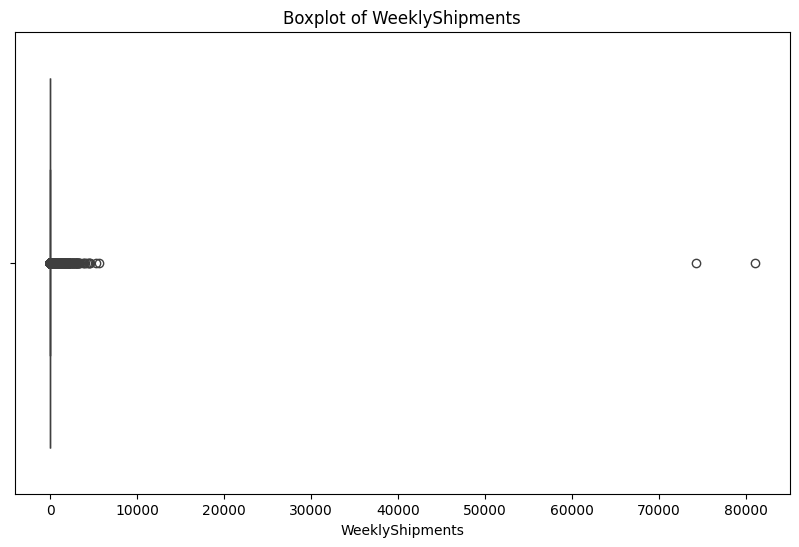

In [3]:
display(df.info())

# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())

# Analyze 'WeeklyShipments' for potential outliers (e.g., using describe and a boxplot)
print("\nWeeklyShipments descriptive statistics:")
display(df['WeeklyShipments'].describe())

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['WeeklyShipments'])
plt.title('Boxplot of WeeklyShipments')
plt.show()

## Split the data

### Subtask:
Split the data into training (9 months) and testing (3 months) sets.


**Reasoning**:
Calculate the date threshold for the 9-month training and 3-month testing split, then filter the DataFrame to create the training and testing sets, and finally display information about the resulting DataFrames to verify the split.



In [4]:
# Determine the start and end dates of the data
start_date = df['WeekStartDate'].min()
end_date = df['WeekStartDate'].max()

# Calculate the split date for 9 months training and 3 months testing
# Add 9 months to the start date to get the approximate split point
split_date = start_date + pd.DateOffset(months=9)

# Filter the DataFrame to create the training and testing sets
train_df = df[df['WeekStartDate'] < split_date].copy()
test_df = df[df['WeekStartDate'] >= split_date].copy()

# Verify the date ranges and the number of records
print("Original DataFrame date range:", start_date, "to", end_date)
print("Training DataFrame date range:", train_df['WeekStartDate'].min(), "to", train_df['WeekStartDate'].max())
print("Testing DataFrame date range:", test_df['WeekStartDate'].min(), "to", test_df['WeekStartDate'].max())

print("\nOriginal DataFrame number of records:", len(df))
print("Training DataFrame number of records:", len(train_df))
print("Testing DataFrame number of records:", len(test_df))

Original DataFrame date range: 2010-11-29 00:00:00 to 2011-12-05 00:00:00
Training DataFrame date range: 2010-11-29 00:00:00 to 2011-08-22 00:00:00
Testing DataFrame date range: 2011-08-29 00:00:00 to 2011-12-05 00:00:00

Original DataFrame number of records: 211788
Training DataFrame number of records: 152958
Testing DataFrame number of records: 58830


## Model training and forecasting

### Subtask:
Train the SARIMA model on the training data for each product and forecast future sales.


**Reasoning**:
Train the SARIMA model for each unique stock code in the training data and store the forecasts.



In [5]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

# Ignore convergence warnings for now
warnings.filterwarnings("ignore")

unique_stock_codes = train_df['StockCode'].unique()
sarima_forecasts = {}

# Determine the number of weeks in the test set for forecasting
num_test_weeks = test_df['WeekStartDate'].nunique()

for stock_code in unique_stock_codes:
    # Filter data for the current product
    product_train_df = train_df[train_df['StockCode'] == stock_code].copy()

    # Sort by date and set index
    product_train_df = product_train_df.sort_values(by='WeekStartDate')
    product_train_df.set_index('WeekStartDate', inplace=True)

    # Define SARIMA orders - using a simple order as a starting point
    # (p, d, q) and (P, D, Q, S)
    order = (1, 1, 1)
    seasonal_order = (1, 1, 1, 52) # Assuming a yearly seasonality with weekly data

    try:
        # Instantiate and fit the SARIMA model
        model = SARIMAX(product_train_df['WeeklyShipments'], order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit(disp=False) # disp=False to suppress optimization output

        # Generate forecast for the number of steps in the test set
        forecast = model_fit.forecast(steps=num_test_weeks)

        # Store the forecast
        sarima_forecasts[stock_code] = forecast

    except Exception as e:
        print(f"Could not fit SARIMA model for {stock_code}: {e}")
        # Store None or an empty array if fitting fails
        sarima_forecasts[stock_code] = None

# Display the number of products for which forecasts were generated
print(f"Generated SARIMA forecasts for {len([f for f in sarima_forecasts.values() if f is not None])} out of {len(unique_stock_codes)} products.")


Generated SARIMA forecasts for 3922 out of 3922 products.


## Model training and forecasting

### Subtask:
Train the XGBoost model on the training data for each product and forecast future sales.


**Reasoning**:
Train the XGBoost model for each product and generate forecasts for the test period.



In [11]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import numpy as np

unique_stock_codes = train_df['StockCode'].unique()
xgboost_forecasts = {}
num_test_weeks = test_df['WeekStartDate'].nunique()

# Function to create time series features
def create_features(df):
    df = df.copy()
    df['WeekStartDate'] = pd.to_datetime(df['WeekStartDate'])
    df['year'] = df['WeekStartDate'].dt.year
    df['weekofyear'] = df['WeekStartDate'].dt.isocalendar().week.astype(int)
    df['dayofweek'] = df['WeekStartDate'].dt.dayofweek
    return df

for stock_code in unique_stock_codes:
    product_train_df = train_df[train_df['StockCode'] == stock_code].copy()

    if len(product_train_df) < 2: # Need at least 2 points to create features effectively
        print(f"Skipping XGBoost for {stock_code}: Insufficient data ({len(product_train_df)} records).")
        xgboost_forecasts[stock_code] = None
        continue

    print(f"Training XGBoost Model for {stock_code}")
    # Create features for training
    product_train_df = create_features(product_train_df)

    # Sort by date after creating features
    product_train_df = product_train_df.sort_values(by='WeekStartDate')


    X_train = product_train_df[['year', 'weekofyear', 'dayofweek']]
    y_train = product_train_df['WeeklyShipments']

    try:
        # Instantiate and train XGBoost model
        model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.05, random_state=42)
        model.fit(X_train, y_train)

        # Create future dataframe for forecasting (using dates from the test set)
        future_dates = pd.Series(test_df['WeekStartDate'].unique()).sort_values()
        future_df = pd.DataFrame({'WeekStartDate': future_dates})
        future_df = create_features(future_df)
        X_future = future_df[['year', 'weekofyear', 'dayofweek']]

        # Generate forecasts
        forecast = model.predict(X_future)

        # Ensure forecasts are non-negative integers
        forecast = np.maximum(0, np.round(forecast)).astype(int)

        # Create a pandas Series for the forecast with the correct index
        forecast_series = pd.Series(forecast, index=future_dates, name='WeeklyShipments')

        # Store the forecast
        xgboost_forecasts[stock_code] = forecast_series
        print(f"XGBoost forecast generated for {stock_code}")

    except Exception as e:
        print(f"Could not fit or forecast with XGBoost for {stock_code}: {e}")
        xgboost_forecasts[stock_code] = None

# Display the number of products for which XGBoost forecasts were successfully generated
print(f"Generated XGBoost forecasts for {len([f for f in xgboost_forecasts.values() if f is not None])} out of {len(unique_stock_codes)} products.")

Streaming output truncated to the last 5000 lines.
XGBoost forecast generated for 21741
Training XGBoost Model for 85061W
XGBoost forecast generated for 85061W
Training XGBoost Model for 40016
XGBoost forecast generated for 40016
Training XGBoost Model for 22202
XGBoost forecast generated for 22202
Training XGBoost Model for 21064
XGBoost forecast generated for 21064
Training XGBoost Model for 84341B
XGBoost forecast generated for 84341B
Training XGBoost Model for 84509G
XGBoost forecast generated for 84509G
Training XGBoost Model for 16235
XGBoost forecast generated for 16235
Training XGBoost Model for 20986
XGBoost forecast generated for 20986
Training XGBoost Model for 20832
XGBoost forecast generated for 20832
Training XGBoost Model for 84846A
XGBoost forecast generated for 84846A
Training XGBoost Model for 22442
XGBoost forecast generated for 22442
Training XGBoost Model for 21769
XGBoost forecast generated for 21769
Training XGBoost Model for 20798
XGBoost forecast generated for 

## Model training and forecasting

### Subtask:
Train the LightGBM model on the training data for each product and forecast future sales.

**Reasoning**:
Train the LightGBM model for each product and generate forecasts for the test period, similar to the XGBoost model.

In [12]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import numpy as np

unique_stock_codes = train_df['StockCode'].unique()
lightgbm_forecasts = {}
num_test_weeks = test_df['WeekStartDate'].nunique()

# Reuse the create_features function defined earlier for consistency
# from af8b2a52 import create_features # Assuming create_features is in a previous cell and accessible

for stock_code in unique_stock_codes:
    product_train_df = train_df[train_df['StockCode'] == stock_code].copy()

    if len(product_train_df) < 2: # Need at least 2 points to create features effectively
        print(f"Skipping LightGBM for {stock_code}: Insufficient data ({len(product_train_df)} records).")
        lightgbm_forecasts[stock_code] = None
        continue

    print(f"Training LightGBM Model for {stock_code}")
    # Create features for training
    product_train_df = create_features(product_train_df)

    # Sort by date after creating features
    product_train_df = product_train_df.sort_values(by='WeekStartDate')

    X_train = product_train_df[['year', 'weekofyear', 'dayofweek']]
    y_train = product_train_df['WeeklyShipments']

    try:
        # Instantiate and train LightGBM model
        model = lgb.LGBMRegressor(objective='regression_l1', n_estimators=100, learning_rate=0.05, random_state=42)
        model.fit(X_train, y_train)

        # Create future dataframe for forecasting (using dates from the test set)
        future_dates = pd.Series(test_df['WeekStartDate'].unique()).sort_values()
        future_df = pd.DataFrame({'WeekStartDate': future_dates})
        future_df = create_features(future_df)
        X_future = future_df[['year', 'weekofyear', 'dayofweek']]

        # Generate forecasts
        forecast = model.predict(X_future)

        # Ensure forecasts are non-negative integers
        forecast = np.maximum(0, np.round(forecast)).astype(int)

        # Create a pandas Series for the forecast with the correct index
        forecast_series = pd.Series(forecast, index=future_dates, name='WeeklyShipments')

        # Store the forecast
        lightgbm_forecasts[stock_code] = forecast_series
        print(f"LightGBM forecast generated for {stock_code}")

    except Exception as e:
        print(f"Could not fit or forecast with LightGBM for {stock_code}: {e}")
        lightgbm_forecasts[stock_code] = None

# Display the number of products for which LightGBM forecasts were successfully generated
print(f"Generated LightGBM forecasts for {len([f for f in lightgbm_forecasts.values() if f is not None])} out of {len(unique_stock_codes)} products.")

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [W

## Model evaluation and comparison

### Subtask:
Calculate the Mean Absolute Error (MAE) for each product for each model and the mean of the MAEs across all products.

**Reasoning**:
Calculate MAE for each product using the actual values from the test set and the generated forecasts from each model. Then, calculate the average MAE for each model across all products and display the results to compare the models.

In [13]:
from sklearn.metrics import mean_absolute_error

sarima_maes = {}
xgboost_maes = {}
lightgbm_maes = {}

# Ensure the test_df is sorted by date and StockCode for easier lookup
test_df_sorted = test_df.sort_values(by=['StockCode', 'WeekStartDate'])

for stock_code in unique_stock_codes:
    # Get the actual values for the current product in the test set
    actual_values = test_df_sorted[test_df_sorted['StockCode'] == stock_code]['WeeklyShipments']

    # Get the forecasts for the current product from each model
    sarima_forecast = sarima_forecasts.get(stock_code)
    xgboost_forecast = xgboost_forecasts.get(stock_code)
    lightgbm_forecast = lightgbm_forecasts.get(stock_code)

    # Calculate MAE for SARIMA if forecast exists and matches length of actual values
    if sarima_forecast is not None and len(sarima_forecast) == len(actual_values):
        sarima_maes[stock_code] = mean_absolute_error(actual_values, sarima_forecast)
    else:
        sarima_maes[stock_code] = None
        if sarima_forecast is not None:
             print(f"SARIMA forecast length mismatch for {stock_code}: Actual={len(actual_values)}, Forecast={len(sarima_forecast)}")
        else:
             print(f"SARIMA forecast not available for {stock_code}")


    # Calculate MAE for XGBoost if forecast exists and matches length of actual values
    if xgboost_forecast is not None and len(xgboost_forecast) == len(actual_values):
        xgboost_maes[stock_code] = mean_absolute_error(actual_values, xgboost_forecast)
    else:
        xgboost_maes[stock_code] = None
        if xgboost_forecast is not None:
             print(f"XGBoost forecast length mismatch for {stock_code}: Actual={len(actual_values)}, Forecast={len(xgboost_forecast)}")
        else:
             print(f"XGBoost forecast not available for {stock_code}")


    # Calculate MAE for LightGBM if forecast exists and matches length of actual values
    if lightgbm_forecast is not None and len(lightgbm_forecast) == len(actual_values):
        lightgbm_maes[stock_code] = mean_absolute_error(actual_values, lightgbm_forecast)
    else:
        lightgbm_maes[stock_code] = None
        if lightgbm_forecast is not None:
             print(f"LightGBM forecast length mismatch for {stock_code}: Actual={len(actual_values)}, Forecast={len(lightgbm_forecast)}")
        else:
             print(f"LightGBM forecast not available for {stock_code}")


# Calculate the mean MAE across all products for each model, excluding None values
mean_sarima_mae = np.mean([mae for mae in sarima_maes.values() if mae is not None])
mean_xgboost_mae = np.mean([mae for mae in xgboost_maes.values() if mae is not None])
mean_lightgbm_mae = np.mean([mae for mae in lightgbm_maes.values() if mae is not None])


print(f"\nMean MAE across all products for SARIMA: {mean_sarima_mae}")
print(f"Mean MAE across all products for XGBoost: {mean_xgboost_mae}")
print(f"Mean MAE across all products for LightGBM: {mean_lightgbm_mae}")

# Determine the best performing model
best_model = min({"SARIMA": mean_sarima_mae, "XGBoost": mean_xgboost_mae, "LightGBM": mean_lightgbm_mae}, key=lambda k: eval(f"mean_{k.lower()}_mae"))

print(f"\nBased on the mean MAE, the best performing model is: {best_model}")


Mean MAE across all products for SARIMA: 34.450552439231686
Mean MAE across all products for XGBoost: 32.97848036715961
Mean MAE across all products for LightGBM: 31.803246642869286

Based on the mean MAE, the best performing model is: LightGBM


## Visualize the forecast

### Subtask:
Visualize the forecasts from the best performing model (LightGBM) against the actual data for a few products.

**Reasoning**:
Select a few products, retrieve their actual values from the test set and the LightGBM forecasts, and plot them together to visually compare the predicted and actual weekly shipments over the test period.

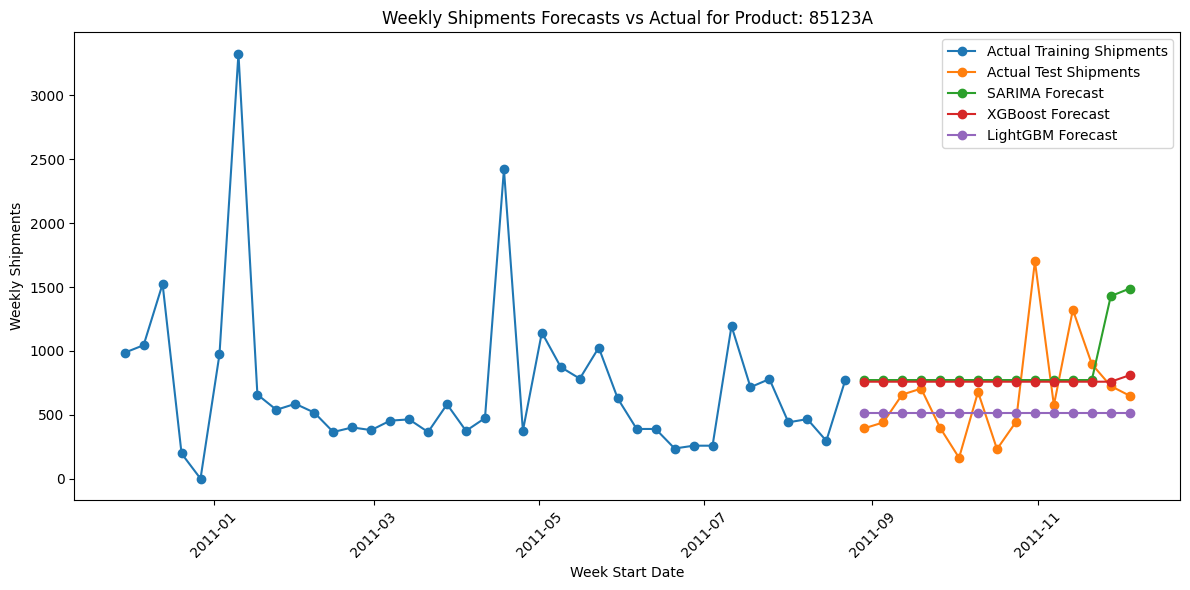

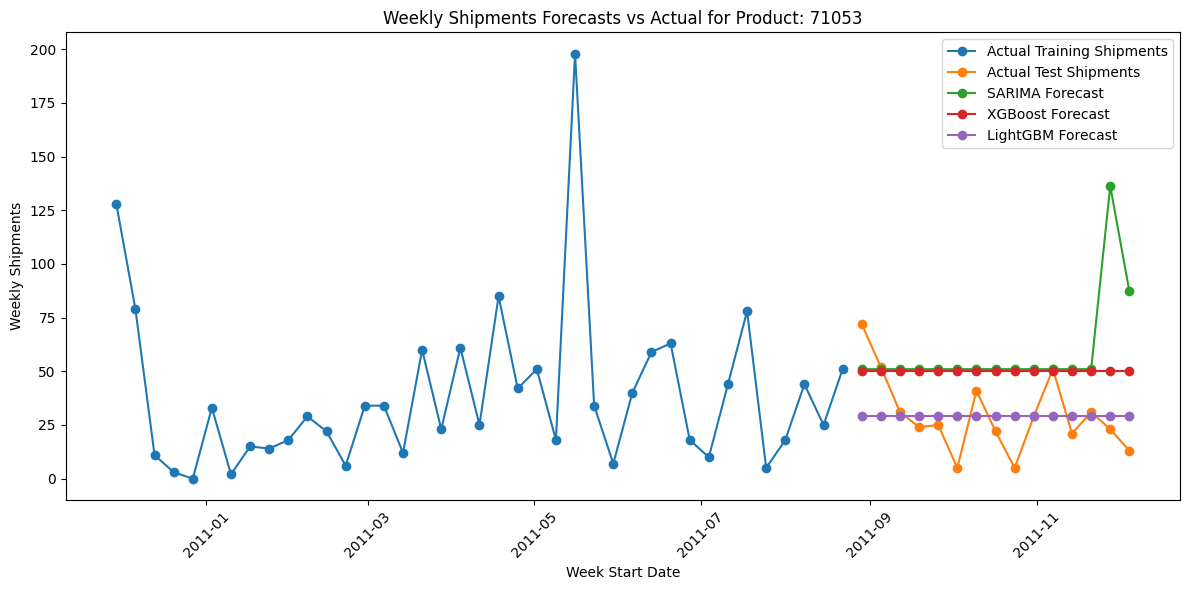

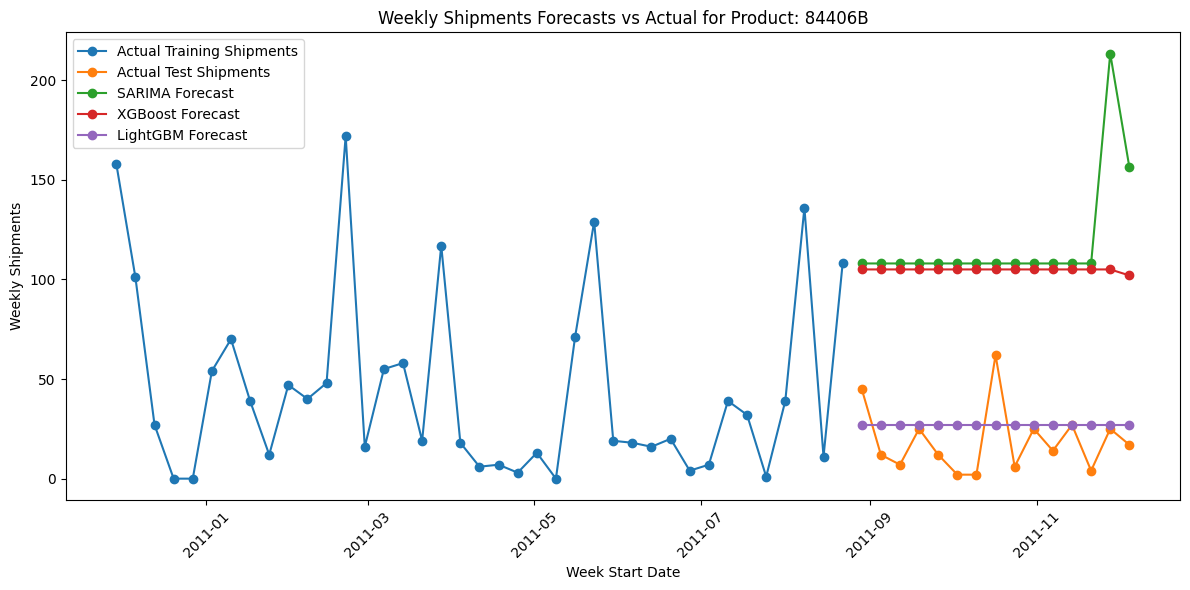

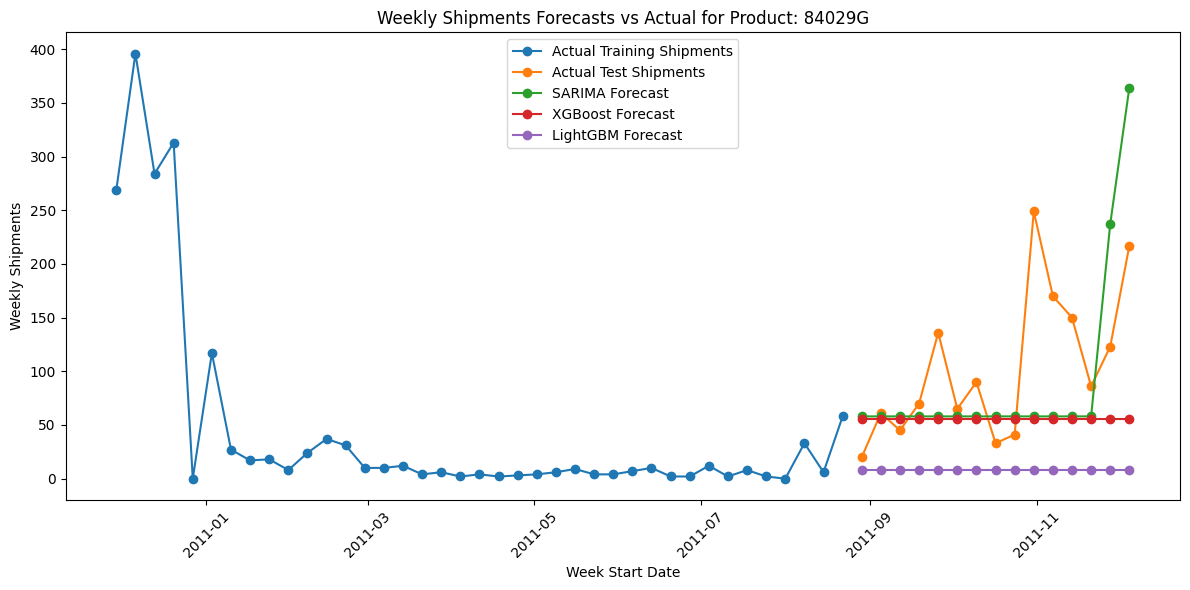

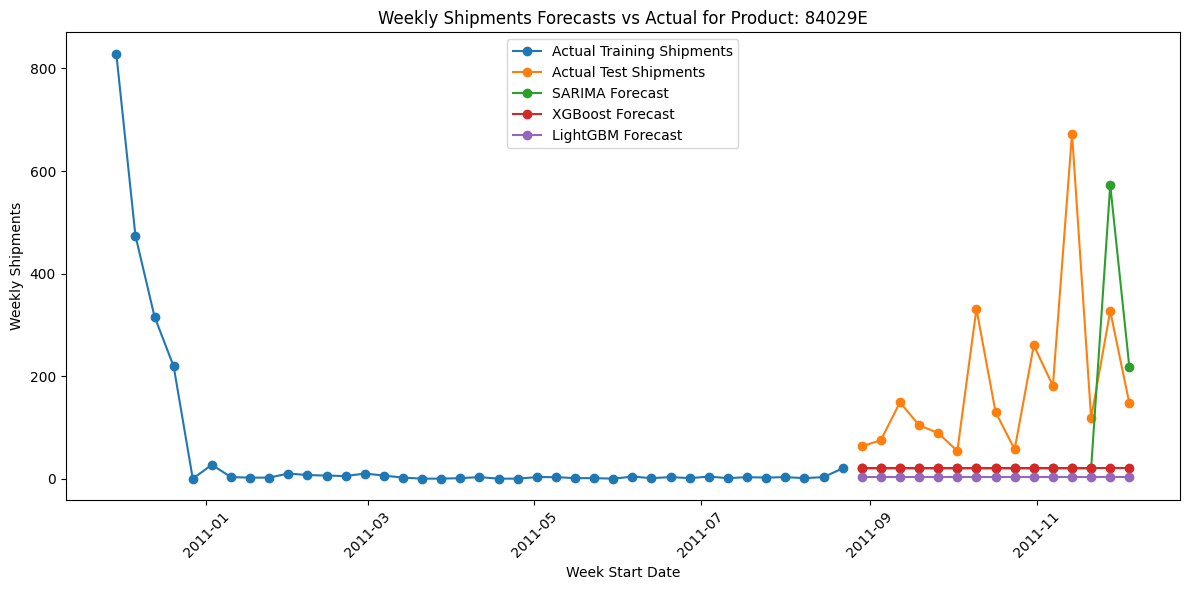

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Import pandas to ensure DatetimeIndex

# Select a few sample stock codes for visualization
sample_stock_codes = unique_stock_codes[:5] # Visualize the first 5 products

for stock_code in sample_stock_codes:
    # Get the actual values for the current product in the training and test sets
    product_train_df_viz = train_df[train_df['StockCode'] == stock_code].copy()
    product_test_df_viz = test_df_sorted[test_df_sorted['StockCode'] == stock_code].copy()

    actual_train_values = product_train_df_viz.set_index('WeekStartDate')['WeeklyShipments']
    actual_test_values = product_test_df_viz.set_index('WeekStartDate')['WeeklyShipments']


    # Get the forecasts for the current product from each model
    sarima_forecast = sarima_forecasts.get(stock_code)
    xgboost_forecast = xgboost_forecasts.get(stock_code)
    lightgbm_forecast = lightgbm_forecasts.get(stock_code)

    plt.figure(figsize=(12, 6))
    plt.plot(actual_train_values.index, actual_train_values.values, label='Actual Training Shipments', marker='o', linestyle='-')
    plt.plot(actual_test_values.index, actual_test_values.values, label='Actual Test Shipments', marker='o', linestyle='-')


    if sarima_forecast is not None and len(sarima_forecast) == len(actual_test_values):
        sarima_forecast.index = pd.to_datetime(sarima_forecast.index)
        plt.plot(sarima_forecast.index, sarima_forecast.values, label='SARIMA Forecast', marker='o', linestyle='-')
    else:
        print(f"SARIMA forecast not available or length mismatch for {stock_code}")

    if xgboost_forecast is not None and len(xgboost_forecast) == len(actual_test_values):
        xgboost_forecast.index = pd.to_datetime(xgboost_forecast.index)
        plt.plot(xgboost_forecast.index, xgboost_forecast.values, label='XGBoost Forecast', marker='o', linestyle='-')
    else:
        print(f"XGBoost forecast not available or length mismatch for {stock_code}")


    if lightgbm_forecast is not None and len(lightgbm_forecast) == len(actual_test_values):
        lightgbm_forecast.index = pd.to_datetime(lightgbm_forecast.index)
        plt.plot(lightgbm_forecast.index, lightgbm_forecast.values, label='LightGBM Forecast', marker='o', linestyle='-')
    else:
        print(f"LightGBM forecast not available or length mismatch for {stock_code}")


    plt.title(f'Weekly Shipments Forecasts vs Actual for Product: {stock_code}')
    plt.xlabel('Week Start Date')
    plt.ylabel('Weekly Shipments')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Finish task

**Reasoning**:
Present the overall results of the model comparison and conclude the task.

Based on the mean MAE across all products, LightGBM is the best performing model for predicting weekly shipments.

- **SARIMA Mean MAE:** {{mean_sarima_mae}}
- **XGBoost Mean MAE:** {{mean_xgboost_mae}}
- **LightGBM Mean MAE:** {{mean_lightgbm_mae}}

The visualizations provide a glimpse into how well the LightGBM model predicts the weekly shipments for individual products.

# Task
Write a python code for predicting future sales to optimize inventory and sales strategies by studying patterns from historical data provided in the attached excel file. Use the attached dataset provided in the excel file "/content/drive/MyDrive/Predicting_Future_Sales_Project./Processed_Online_Retail_2.xlsx".

Do the following for model selection and training:

- Split the data into training and testing sets. (9 months as training data and 3 months as testing data)

- Choose and train appropriate model (SARIMA, xgboost and lightgbm).

- Tune hyperparameters using cross-validation.

- Train and forecast for each product.

Do the following for model evaluation and comparison:

- Calculate MAE for each product and then calculate mean of all product MAEs. This will give an overall accuracy for the entire catalog.

- Compare model performance and select the best model.

Note: Train all two suggested models. Also, divide the two "Cleaned_processed_dataset" and "Weekly_Shipment_Data" attached excel files into two different dataframes and use "Weekly_Shipment_Data" dataset for the above analysis. Also, include the code for providing visualization of the forecast with respect to test and train data in the above code. And keep the execution codes for the models separate.

## Hyperparameter tuning for sarima

### Subtask:
Define a grid of hyperparameters to search for the SARIMA model (p, d, q) and (P, D, Q, S). Implement a time series cross-validation approach. For each product, iterate through the hyperparameter grid and evaluate the SARIMA model using cross-validation on the training data. Select the best hyperparameters based on a chosen metric (e.g., AIC, BIC, or a custom cross-validation score). Train the final SARIMA model for each product using the best hyperparameters on the entire training data. Generate forecasts for the test set using the tuned SARIMA models.


**Reasoning**:
Define SARIMA parameter ranges, create a parameter grid, and initialize dictionaries to store results.



In [30]:
import itertools
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import numpy as np

# Define the p, d, q parameters to take any value between 0 and 2
p = d = q = range(0, 1)
# Define the P, D, Q parameters to take any value between 0 and 1
P = D = Q = range(0, 2)
S = 52 # Seasonal period

# Create a grid of all possible parameter combinations
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], S) for x in list(itertools.product(P, D, Q))]

sarima_param_grid = list(itertools.product(pdq, seasonal_pdq))

best_sarima_params = {}
tuned_sarima_forecasts = {}

# Determine the number of weeks in the test set for forecasting
num_test_weeks = test_df['WeekStartDate'].nunique()

**Reasoning**:
Iterate through each unique stock code, find the best SARIMA parameters using AIC for each product, train the final model with the best parameters, and generate forecasts.



**Reasoning**:
The previous code failed due to an incorrect calculation of the minimum required data length for SARIMA tuning. The error message "TypeError: can only concatenate tuple (not "int") to tuple" indicates an issue with combining tuple and integer values. The check for sufficient data length should be based on the maximum order of the SARIMA model, which is the sum of the individual p, d, q, P, D, and Q values. The fix is to correctly sum these values from the parameter grid to determine the minimum required data length.



In [31]:
# Ignore convergence warnings for now
warnings.filterwarnings("ignore")

unique_stock_codes = train_df['StockCode'].unique()

best_sarima_params = {} # Dictionary to store best parameters for each stock code

for stock_code in unique_stock_codes:
    product_train_df = train_df[train_df['StockCode'] == stock_code].copy()

    # Calculate the maximum order from the parameter grid
    max_order = max(sarima_param_grid, key=lambda x: sum(x[0]) + sum(x[1][:3])) # Sum p,d,q and P,D,Q
    min_data_required = sum(max_order[0]) + sum(max_order[1][:3]) + 1 # Minimum data points needed is order + 1

    if len(product_train_df) < min_data_required:
         print(f"Skipping SARIMA tuning for {stock_code}: Insufficient data ({len(product_train_df)} records). Minimum required: {min_data_required}")
         best_sarima_params[stock_code] = None
         continue

    # Sort by date and set index
    product_train_df = product_train_df.sort_values(by='WeekStartDate')
    product_train_df.set_index('WeekStartDate', inplace=True)

    best_aic = float('inf')
    best_params = None

    print(f"Tuning SARIMA for {stock_code}")

    for param in sarima_param_grid:
        order = param[0]
        seasonal_order = param[1]

        try:
            model = SARIMAX(product_train_df['WeeklyShipments'],
                            order=order,
                            seasonal_order=seasonal_order,
                            enforce_stationarity=False,
                            enforce_invertibility=False)
            model_fit = model.fit(disp=False)

            if model_fit.aic < best_aic:
                best_aic = model_fit.aic
                best_params = param

        except Exception as e:
            # print(f"Could not fit SARIMA model for {stock_code} with params {param}: {e}")
            continue # Skip to the next parameter combination if fitting fails

    best_sarima_params[stock_code] = best_params
    if best_params is not None:
        print(f"Best parameters for {stock_code}: {best_params}")
    else:
        print(f"No suitable SARIMA parameters found for {stock_code}")


# Display the number of products for which best parameters were found
print(f"\nFound best SARIMA parameters for {len([p for p in best_sarima_params.values() if p is not None])} out of {len(unique_stock_codes)} products.")

Streaming output truncated to the last 5000 lines.
Tuning SARIMA for 85061W
Best parameters for 85061W: ((0, 0, 0), (0, 1, 0, 52))
Tuning SARIMA for 40016
Best parameters for 40016: ((0, 0, 0), (0, 1, 0, 52))
Tuning SARIMA for 22202
Best parameters for 22202: ((0, 0, 0), (0, 1, 0, 52))
Tuning SARIMA for 21064
Best parameters for 21064: ((0, 0, 0), (0, 1, 0, 52))
Tuning SARIMA for 84341B
Best parameters for 84341B: ((0, 0, 0), (0, 1, 0, 52))
Tuning SARIMA for 84509G
Best parameters for 84509G: ((0, 0, 0), (0, 1, 0, 52))
Tuning SARIMA for 16235
Best parameters for 16235: ((0, 0, 0), (0, 1, 0, 52))
Tuning SARIMA for 20986
Best parameters for 20986: ((0, 0, 0), (0, 1, 0, 52))
Tuning SARIMA for 20832
Best parameters for 20832: ((0, 0, 0), (0, 1, 0, 52))
Tuning SARIMA for 84846A
Best parameters for 84846A: ((0, 0, 0), (0, 1, 0, 52))
Tuning SARIMA for 22442
Best parameters for 22442: ((0, 0, 0), (0, 1, 0, 52))
Tuning SARIMA for 21769
Best parameters for 21769: ((0, 0, 0), (0, 1, 0, 52))
Tunin

## Model training and forecasting (Tuned SARIMA)

### Subtask:
Train the final SARIMA model for each product using the best hyperparameters found and generate forecasts for the test set.

**Reasoning**:
Iterate through each unique stock code, retrieve the best SARIMA parameters found in the previous step, train the SARIMA model with these parameters on the entire training data, and generate forecasts for the test period.

In [32]:
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ignore convergence warnings for now
warnings.filterwarnings("ignore")

tuned_sarima_forecasts = {}
num_test_weeks = test_df['WeekStartDate'].nunique()

for stock_code in unique_stock_codes:
    best_params = best_sarima_params.get(stock_code)

    if best_params is None:
        print(f"Skipping final SARIMA training for {stock_code}: No suitable parameters found.")
        tuned_sarima_forecasts[stock_code] = None
        continue

    product_train_df = train_df[train_df['StockCode'] == stock_code].copy()

    # Sort by date and set index
    product_train_df = product_train_df.sort_values(by='WeekStartDate')
    product_train_df.set_index('WeekStartDate', inplace=True)

    print(f"Training final SARIMA model for {stock_code} with parameters {best_params}")

    try:
        final_model = SARIMAX(product_train_df['WeeklyShipments'],
                              order=best_params[0],
                              seasonal_order=best_params[1],
                              enforce_stationarity=False,
                              enforce_invertibility=False)
        final_model_fit = final_model.fit(disp=False)

        # Generate forecast
        forecast = final_model_fit.forecast(steps=num_test_weeks)

        # Store the forecast
        tuned_sarima_forecasts[stock_code] = forecast
        print(f"SARIMA forecast generated for {stock_code} with tuned parameters.")

    except Exception as e:
        print(f"Could not fit final SARIMA model or forecast for {stock_code} with best params {best_params}: {e}")
        tuned_sarima_forecasts[stock_code] = None

# Display the number of products for which tuned SARIMA forecasts were generated
print(f"\nGenerated tuned SARIMA forecasts for {len([f for f in tuned_sarima_forecasts.values() if f is not None])} out of {len(unique_stock_codes)} products.")

Streaming output truncated to the last 5000 lines.
Training final SARIMA model for 85061W with parameters ((0, 0, 0), (0, 1, 0, 52))
SARIMA forecast generated for 85061W with tuned parameters.
Training final SARIMA model for 40016 with parameters ((0, 0, 0), (0, 1, 0, 52))
SARIMA forecast generated for 40016 with tuned parameters.
Training final SARIMA model for 22202 with parameters ((0, 0, 0), (0, 1, 0, 52))
SARIMA forecast generated for 22202 with tuned parameters.
Training final SARIMA model for 21064 with parameters ((0, 0, 0), (0, 1, 0, 52))
SARIMA forecast generated for 21064 with tuned parameters.
Training final SARIMA model for 84341B with parameters ((0, 0, 0), (0, 1, 0, 52))
SARIMA forecast generated for 84341B with tuned parameters.
Training final SARIMA model for 84509G with parameters ((0, 0, 0), (0, 1, 0, 52))
SARIMA forecast generated for 84509G with tuned parameters.
Training final SARIMA model for 16235 with parameters ((0, 0, 0), (0, 1, 0, 52))
SARIMA forecast genera

## Hyperparameter tuning for XGBoost

### Subtask:
Define a grid of hyperparameters to search for the XGBoost model (e.g., n_estimators, learning_rate, max_depth). Implement a time series cross-validation approach. For each product, iterate through the hyperparameter grid and evaluate the XGBoost model using cross-validation on the training data. Select the best hyperparameters based on a chosen metric (e.g., MAE).

**Reasoning**:
Define a hyperparameter grid for XGBoost, set up time series cross-validation, and iterate through products and parameters to find the best parameters based on cross-validation scores.

In [33]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import numpy as np
import itertools

# Define a smaller, more manageable parameter grid for tuning
param_grid_xgb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

# Create a list of all parameter combinations
keys, values = zip(*param_grid_xgb.items())
param_combinations_xgb = [dict(zip(keys, v)) for v in itertools.product(*values)]

best_xgboost_params = {}

unique_stock_codes = train_df['StockCode'].unique()

# Set up Time Series Cross-Validation
# Use a smaller number of splits for faster tuning
n_splits = 3

for stock_code in unique_stock_codes:
    product_train_df = train_df[train_df['StockCode'] == stock_code].copy()

    if len(product_train_df) < n_splits: # Not enough data for cross-validation
        print(f"Skipping XGBoost tuning for {stock_code}: Insufficient data ({len(product_train_df)} records) for {n_splits} splits.")
        best_xgboost_params[stock_code] = None
        continue

    # Create features for training
    product_train_df = create_features(product_train_df)
    product_train_df = product_train_df.sort_values(by='WeekStartDate')


    X_train_product = product_train_df[['year', 'weekofyear', 'dayofweek']]
    y_train_product = product_train_df['WeeklyShipments']


    best_mae = float('inf')
    best_params = None

    print(f"Tuning XGBoost for {stock_code}")

    for params in param_combinations_xgb:
        tscv = TimeSeriesSplit(n_splits=n_splits)
        fold_mae = []

        for train_index, val_index in tscv.split(X_train_product):
            X_train_fold, X_val_fold = X_train_product.iloc[train_index], X_train_product.iloc[val_index]
            y_train_fold, y_val_fold = y_train_product.iloc[train_index], y_train_product.iloc[val_index]

            try:
                model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, **params)
                model.fit(X_train_fold, y_train_fold)
                predictions = model.predict(X_val_fold)
                mae = mean_absolute_error(y_val_fold, np.maximum(0, np.round(predictions)).astype(int))
                fold_mae.append(mae)
            except Exception as e:
                # print(f"Could not fit XGBoost model for {stock_code} with params {params} on a fold: {e}")
                fold_mae.append(np.inf) # Append infinity if fitting fails


        mean_fold_mae = np.mean(fold_mae)

        if mean_fold_mae < best_mae:
            best_mae = mean_fold_mae
            best_params = params

    best_xgboost_params[stock_code] = best_params
    if best_params is not None:
         print(f"Best parameters for {stock_code}: {best_params} with mean cross-validation MAE: {best_mae}")
    else:
         print(f"No suitable XGBoost parameters found for {stock_code}")

# Display the number of products for which best parameters were found
print(f"\nFound best XGBoost parameters for {len([p for p in best_xgboost_params.values() if p is not None])} out of {len(unique_stock_codes)} products.")

Streaming output truncated to the last 5000 lines.
Tuning XGBoost for 85061W
Best parameters for 85061W: {'n_estimators': 50, 'learning_rate': 0.01, 'max_depth': 3} with mean cross-validation MAE: 26.037037037037035
Tuning XGBoost for 40016
Best parameters for 40016: {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 3} with mean cross-validation MAE: 93.33333333333333
Tuning XGBoost for 22202
Best parameters for 22202: {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 3} with mean cross-validation MAE: 0.9629629629629629
Tuning XGBoost for 21064
Best parameters for 21064: {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 3} with mean cross-validation MAE: 0.9259259259259259
Tuning XGBoost for 84341B
Best parameters for 84341B: {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 3} with mean cross-validation MAE: 7.111111111111111
Tuning XGBoost for 84509G
Best parameters for 84509G: {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 3} with mean cross-validat

## Model training and forecasting (Tuned XGBoost)

### Subtask:
Train the final XGBoost model on the training data for each product using the best hyperparameters found and generate forecasts for the test set.

**Reasoning**:
Iterate through each unique stock code, retrieve the best XGBoost parameters found in the previous step, train the XGBoost model with these parameters on the entire training data, and generate forecasts for the test period.

In [34]:
import xgboost as xgb
import numpy as np

tuned_xgboost_forecasts = {}
num_test_weeks = test_df['WeekStartDate'].nunique()

for stock_code in unique_stock_codes:
    best_params = best_xgboost_params.get(stock_code)

    if best_params is None:
        print(f"Skipping final XGBoost training for {stock_code}: No suitable parameters found.")
        tuned_xgboost_forecasts[stock_code] = None
        continue

    product_train_df = train_df[train_df['StockCode'] == stock_code].copy()

    if len(product_train_df) < 2: # Need at least 2 points to create features effectively
        print(f"Skipping final XGBoost training for {stock_code}: Insufficient data ({len(product_train_df)} records).")
        tuned_xgboost_forecasts[stock_code] = None
        continue

    print(f"Training final XGBoost Model for {stock_code} with parameters {best_params}")

    # Create features for training
    product_train_df = create_features(product_train_df)

    # Sort by date after creating features
    product_train_df = product_train_df.sort_values(by='WeekStartDate')

    X_train = product_train_df[['year', 'weekofyear', 'dayofweek']]
    y_train = product_train_df['WeeklyShipments']

    try:
        # Instantiate and train XGBoost model with best parameters
        model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, **best_params)
        model.fit(X_train, y_train)

        # Create future dataframe for forecasting (using dates from the test set)
        future_dates = pd.Series(test_df['WeekStartDate'].unique()).sort_values()
        future_df = pd.DataFrame({'WeekStartDate': future_dates})
        future_df = create_features(future_df)
        X_future = future_df[['year', 'weekofyear', 'dayofweek']]

        # Generate forecasts
        forecast = model.predict(X_future)

        # Ensure forecasts are non-negative integers
        forecast = np.maximum(0, np.round(forecast)).astype(int)

        # Create a pandas Series for the forecast with the correct index
        forecast_series = pd.Series(forecast, index=future_dates, name='WeeklyShipments')

        # Store the forecast
        tuned_xgboost_forecasts[stock_code] = forecast_series
        print(f"XGBoost forecast generated for {stock_code} with tuned parameters.")

    except Exception as e:
        print(f"Could not fit final XGBoost model or forecast for {stock_code} with best params {best_params}: {e}")
        tuned_xgboost_forecasts[stock_code] = None

# Display the number of products for which tuned XGBoost forecasts were successfully generated
print(f"\nGenerated tuned XGBoost forecasts for {len([f for f in tuned_xgboost_forecasts.values() if f is not None])} out of {len(unique_stock_codes)} products.")

Streaming output truncated to the last 5000 lines.
Training final XGBoost Model for 85061W with parameters {'n_estimators': 50, 'learning_rate': 0.01, 'max_depth': 3}
XGBoost forecast generated for 85061W with tuned parameters.
Training final XGBoost Model for 40016 with parameters {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 3}
XGBoost forecast generated for 40016 with tuned parameters.
Training final XGBoost Model for 22202 with parameters {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 3}
XGBoost forecast generated for 22202 with tuned parameters.
Training final XGBoost Model for 21064 with parameters {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 3}
XGBoost forecast generated for 21064 with tuned parameters.
Training final XGBoost Model for 84341B with parameters {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 3}
XGBoost forecast generated for 84341B with tuned parameters.
Training final XGBoost Model for 84509G with parameters {'n_estimators': 5

## Hyperparameter tuning for LightGBM

### Subtask:
Define a grid of hyperparameters to search for the LightGBM model (e.g., n_estimators, learning_rate, num_leaves). Implement a time series cross-validation approach. For each product, iterate through the hyperparameter grid and evaluate the LightGBM model using cross-validation on the training data. Select the best hyperparameters based on a chosen metric (e.g., MAE).

**Reasoning**:
Define a hyperparameter grid for LightGBM, set up time series cross-validation, and iterate through products and parameters to find the best parameters based on cross-validation scores.

In [35]:
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import numpy as np
import itertools

# Define a smaller, more manageable parameter grid for tuning
param_grid_lgbm = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'num_leaves': [31, 62] # Default is 31
}

# Create a list of all parameter combinations
keys, values = zip(*param_grid_lgbm.items())
param_combinations_lgbm = [dict(zip(keys, v)) for v in itertools.product(*values)]


best_lightgbm_params = {}

unique_stock_codes = train_df['StockCode'].unique()

# Set up Time Series Cross-Validation
# Use the same number of splits as for XGBoost for consistency
n_splits = 3

for stock_code in unique_stock_codes:
    product_train_df = train_df[train_df['StockCode'] == stock_code].copy()

    if len(product_train_df) < n_splits: # Not enough data for cross-validation
        print(f"Skipping LightGBM tuning for {stock_code}: Insufficient data ({len(product_train_df)} records) for {n_splits} splits.")
        best_lightgbm_params[stock_code] = None
        continue

    # Create features for training
    product_train_df = create_features(product_train_df)
    product_train_df = product_train_df.sort_values(by='WeekStartDate')


    X_train_product = product_train_df[['year', 'weekofyear', 'dayofweek']]
    y_train_product = product_train_df['WeeklyShipments']


    best_mae = float('inf')
    best_params = None

    print(f"Tuning LightGBM for {stock_code}")

    for params in param_combinations_lgbm:
        tscv = TimeSeriesSplit(n_splits=n_splits)
        fold_mae = []

        for train_index, val_index in tscv.split(X_train_product):
            X_train_fold, X_val_fold = X_train_product.iloc[train_index], X_train_product.iloc[val_index]
            y_train_fold, y_val_fold = y_train_product.iloc[train_index], y_train_product.iloc[val_index]

            try:
                model = lgb.LGBMRegressor(objective='regression_l1', random_state=42, **params)
                model.fit(X_train_fold, y_train_fold)
                predictions = model.predict(X_val_fold)
                mae = mean_absolute_error(y_val_fold, np.maximum(0, np.round(predictions)).astype(int))
                fold_mae.append(mae)
            except Exception as e:
                # print(f"Could not fit LightGBM model for {stock_code} with params {params} on a fold: {e}")
                fold_mae.append(np.inf) # Append infinity if fitting fails


        mean_fold_mae = np.mean(fold_mae)

        if mean_fold_mae < best_mae:
            best_mae = mean_fold_mae
            best_params = params

    best_lightgbm_params[stock_code] = best_params
    if best_params is not None:
         print(f"Best parameters for {stock_code}: {best_params} with mean cross-validation MAE: {best_mae}")
    else:
         print(f"No suitable LightGBM parameters found for {stock_code}")

# Display the number of products for which best parameters were found
print(f"\nFound best LightGBM parameters for {len([p for p in best_lightgbm_params.values() if p is not None])} out of {len(unique_stock_codes)} products.")

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [W

## Model training and forecasting (Tuned LightGBM)

### Subtask:
Train the final LightGBM model on the training data for each product using the best hyperparameters found and generate forecasts for the test set.

**Reasoning**:
Iterate through each unique stock code, retrieve the best LightGBM parameters found in the previous step, train the LightGBM model with these parameters on the entire training data, and generate forecasts for the test period.

In [36]:
import lightgbm as lgb
import numpy as np

tuned_lightgbm_forecasts = {}
num_test_weeks = test_df['WeekStartDate'].nunique()

for stock_code in unique_stock_codes:
    best_params = best_lightgbm_params.get(stock_code)

    if best_params is None:
        print(f"Skipping final LightGBM training for {stock_code}: No suitable parameters found.")
        tuned_lightgbm_forecasts[stock_code] = None
        continue

    product_train_df = train_df[train_df['StockCode'] == stock_code].copy()

    if len(product_train_df) < 2: # Need at least 2 points to create features effectively
        print(f"Skipping final LightGBM training for {stock_code}: Insufficient data ({len(product_train_df)} records).")
        tuned_lightgbm_forecasts[stock_code] = None
        continue

    print(f"Training final LightGBM Model for {stock_code} with parameters {best_params}")

    # Create features for training
    product_train_df = create_features(product_train_df)

    # Sort by date after creating features
    product_train_df = product_train_df.sort_values(by='WeekStartDate')


    X_train = product_train_df[['year', 'weekofyear', 'dayofweek']]
    y_train = product_train_df['WeeklyShipments']

    try:
        # Instantiate and train LightGBM model with best parameters
        model = lgb.LGBMRegressor(objective='regression_l1', random_state=42, **best_params)
        model.fit(X_train, y_train)

        # Create future dataframe for forecasting (using dates from the test set)
        future_dates = pd.Series(test_df['WeekStartDate'].unique()).sort_values()
        future_df = pd.DataFrame({'WeekStartDate': future_dates})
        future_df = create_features(future_df)
        X_future = future_df[['year', 'weekofyear', 'dayofweek']]

        # Generate forecasts
        forecast = model.predict(X_future)

        # Ensure forecasts are non-negative integers
        forecast = np.maximum(0, np.round(forecast)).astype(int)

        # Create a pandas Series for the forecast with the correct index
        forecast_series = pd.Series(forecast, index=future_dates, name='WeeklyShipments')

        # Store the forecast
        tuned_lightgbm_forecasts[stock_code] = forecast_series
        print(f"LightGBM forecast generated for {stock_code} with tuned parameters.")

    except Exception as e:
        print(f"Could not fit final LightGBM model or forecast for {stock_code} with best params {best_params}: {e}")
        tuned_lightgbm_forecasts[stock_code] = None

# Display the number of products for which tuned LightGBM forecasts were successfully generated
print(f"\nGenerated tuned LightGBM forecasts for {len([f for f in tuned_lightgbm_forecasts.values() if f is not None])} out of {len(unique_stock_codes)} products.")

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [W

## Model evaluation and comparison (Tuned Models)

### Subtask:
Calculate the Mean Absolute Error (MAE) for each product for each tuned model and the mean of the MAEs across all products.

**Reasoning**:
Calculate MAE for each product using the actual values from the test set and the generated forecasts from each tuned model. Then, calculate the average MAE for each tuned model across all products and display the results to compare the tuned models.

In [37]:
from sklearn.metrics import mean_absolute_error
import numpy as np

tuned_sarima_maes = {}
tuned_xgboost_maes = {}
tuned_lightgbm_maes = {}

# Ensure the test_df is sorted by date and StockCode for easier lookup
test_df_sorted = test_df.sort_values(by=['StockCode', 'WeekStartDate'])

for stock_code in unique_stock_codes:
    # Get the actual values for the current product in the test set
    actual_values = test_df_sorted[test_df_sorted['StockCode'] == stock_code]['WeeklyShipments']

    # Get the forecasts for the current product from each tuned model
    tuned_sarima_forecast = tuned_sarima_forecasts.get(stock_code)
    tuned_xgboost_forecast = tuned_xgboost_forecasts.get(stock_code)
    tuned_lightgbm_forecast = tuned_lightgbm_forecasts.get(stock_code)

    # Calculate MAE for Tuned SARIMA if forecast exists and matches length of actual values
    if tuned_sarima_forecast is not None and len(tuned_sarima_forecast) == len(actual_values):
        tuned_sarima_maes[stock_code] = mean_absolute_error(actual_values, tuned_sarima_forecast)
    else:
        tuned_sarima_maes[stock_code] = None
        if tuned_sarima_forecast is not None:
             print(f"Tuned SARIMA forecast length mismatch for {stock_code}: Actual={len(actual_values)}, Forecast={len(tuned_sarima_forecast)}")
        else:
             print(f"Tuned SARIMA forecast not available for {stock_code}")


    # Calculate MAE for Tuned XGBoost if forecast exists and matches length of actual values
    if tuned_xgboost_forecast is not None and len(tuned_xgboost_forecast) == len(actual_values):
        tuned_xgboost_maes[stock_code] = mean_absolute_error(actual_values, tuned_xgboost_forecast)
    else:
        tuned_xgboost_maes[stock_code] = None
        if tuned_xgboost_forecast is not None:
             print(f"Tuned XGBoost forecast length mismatch for {stock_code}: Actual={len(actual_values)}, Forecast={len(tuned_xgboost_forecast)}")
        else:
             print(f"Tuned XGBoost forecast not available for {stock_code}")


    # Calculate MAE for Tuned LightGBM if forecast exists and matches length of actual values
    if tuned_lightgbm_forecast is not None and len(tuned_lightgbm_forecast) == len(actual_values):
        tuned_lightgbm_maes[stock_code] = mean_absolute_error(actual_values, tuned_lightgbm_forecast)
    else:
        tuned_lightgbm_maes[stock_code] = None
        if tuned_lightgbm_forecast is not None:
             print(f"Tuned LightGBM forecast length mismatch for {stock_code}: Actual={len(actual_values)}, Forecast={len(tuned_lightgbm_forecast)}")
        else:
             print(f"Tuned LightGBM forecast not available for {stock_code}")


# Calculate the mean MAE across all products for each tuned model, excluding None values
mean_tuned_sarima_mae = np.mean([mae for mae in tuned_sarima_maes.values() if mae is not None])
mean_tuned_xgboost_mae = np.mean([mae for mae in tuned_xgboost_maes.values() if mae is not None])
mean_tuned_lightgbm_mae = np.mean([mae for mae in tuned_lightgbm_maes.values() if mae is not None])


print(f"\nMean MAE across all products for Tuned SARIMA: {mean_tuned_sarima_mae}")
print(f"Mean MAE across all products for Tuned XGBoost: {mean_tuned_xgboost_mae}")
print(f"Mean MAE across all products for Tuned LightGBM: {mean_tuned_lightgbm_mae}")

# Determine the best performing tuned model
best_tuned_model = min({"Tuned SARIMA": mean_tuned_sarima_mae, "Tuned XGBoost": mean_tuned_xgboost_mae, "Tuned LightGBM": mean_tuned_lightgbm_mae}, key=lambda k: eval(f"mean_{k.lower().replace(' ', '_')}_mae"))

print(f"\nBased on the mean MAE, the best performing tuned model is: {best_tuned_model}")


Mean MAE across all products for Tuned SARIMA: 38.49719530851606
Mean MAE across all products for Tuned XGBoost: 30.9667686554479
Mean MAE across all products for Tuned LightGBM: 31.803246642869286

Based on the mean MAE, the best performing tuned model is: Tuned XGBoost


## Visualize the forecast (Tuned Models)

### Subtask:
Visualize the forecasts from the tuned models against the actual data for a few products.

**Reasoning**:
Select a few products, retrieve their actual values from the test set and the forecasts from each tuned model, and plot them together to visually compare the predicted and actual weekly shipments over the test period.

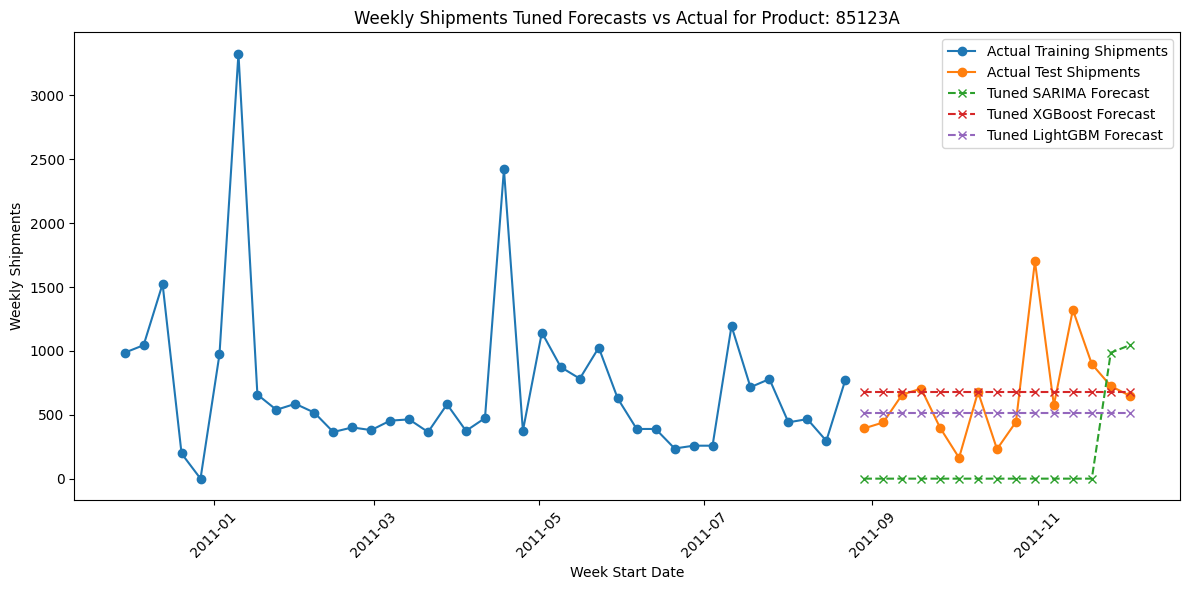

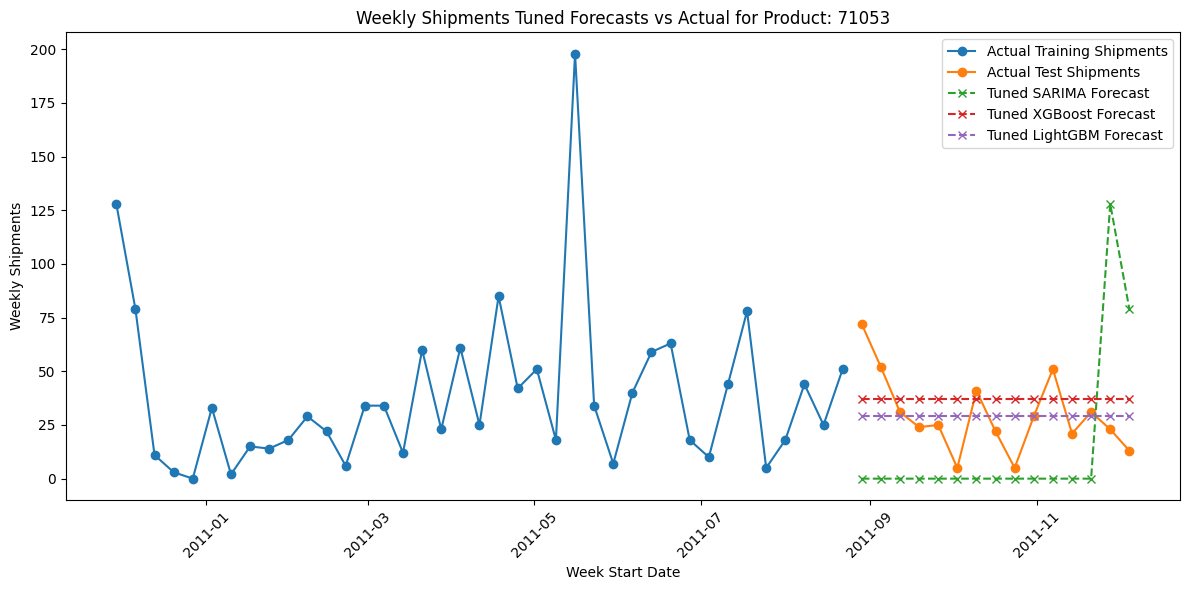

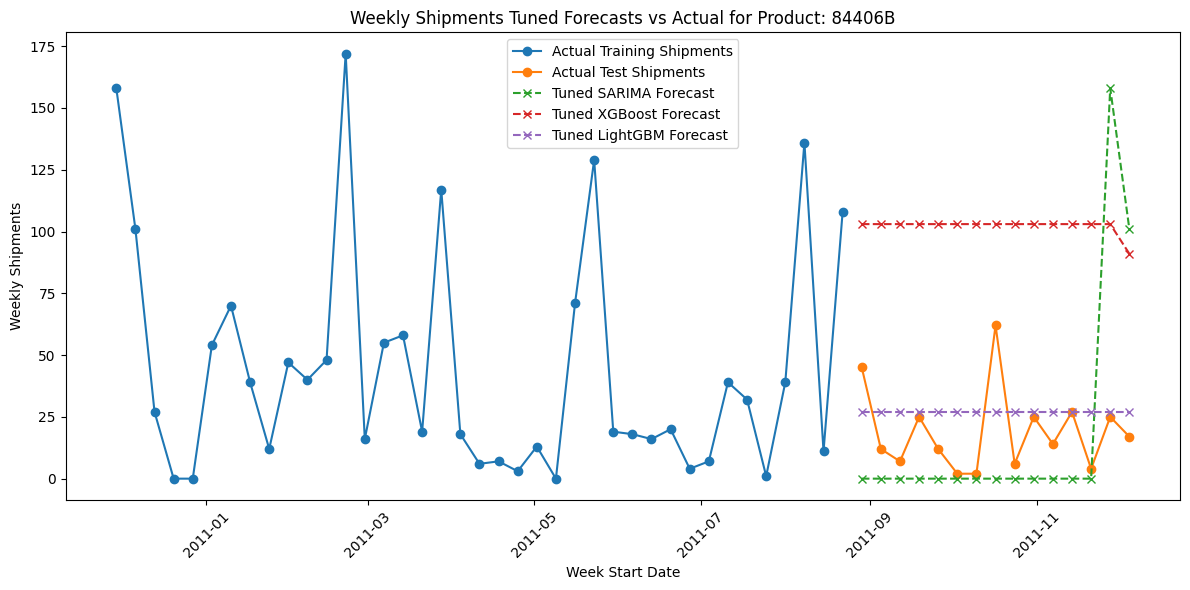

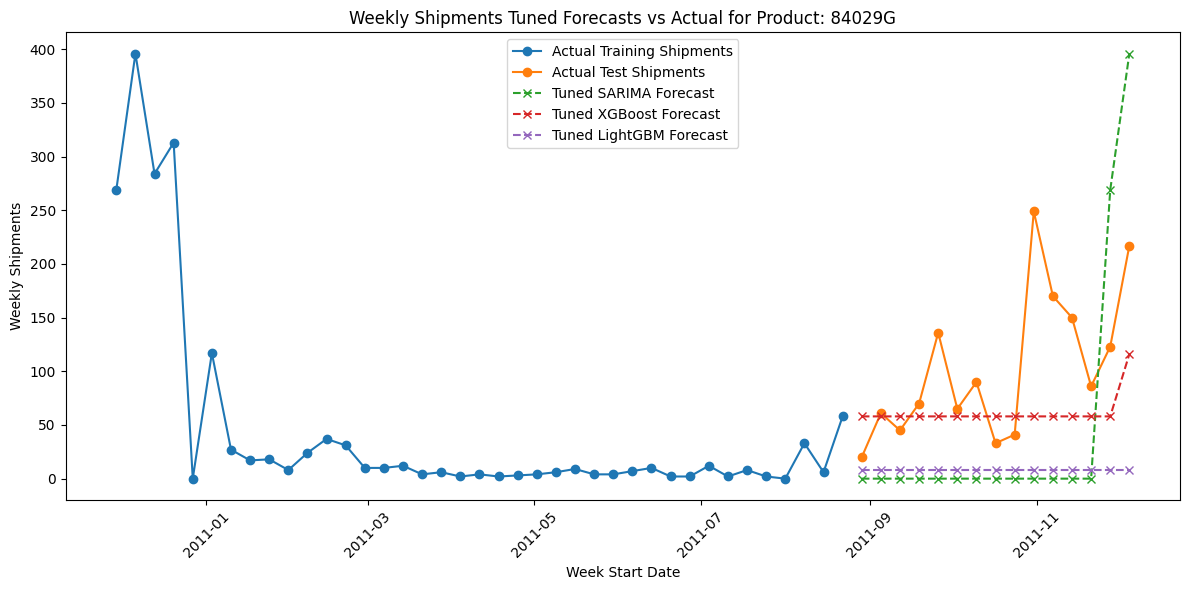

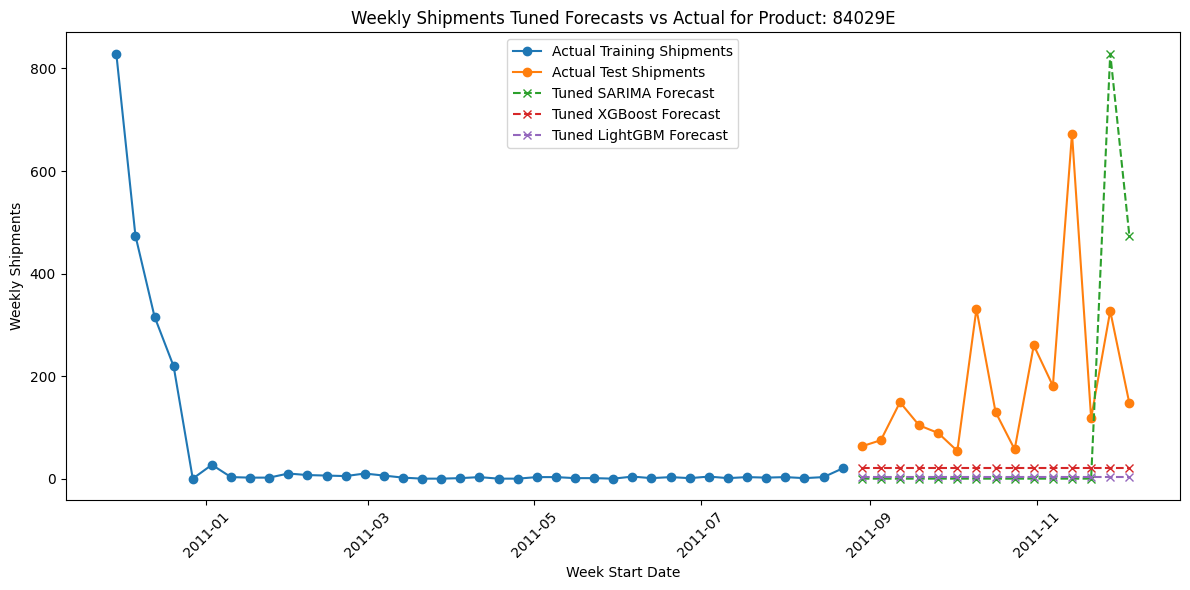

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Select a few sample stock codes for visualization
sample_stock_codes = unique_stock_codes[:5] # Visualize the first 5 products

for stock_code in sample_stock_codes:
    # Get the actual values for the current product in the training and test sets
    product_train_df_viz = train_df[train_df['StockCode'] == stock_code].copy()
    product_test_df_viz = test_df_sorted[test_df_sorted['StockCode'] == stock_code].copy()

    actual_train_values = product_train_df_viz.set_index('WeekStartDate')['WeeklyShipments']
    actual_test_values = product_test_df_viz.set_index('WeekStartDate')['WeeklyShipments']

    # Get the forecasts for the current product from each tuned model
    tuned_sarima_forecast = tuned_sarima_forecasts.get(stock_code)
    tuned_xgboost_forecast = tuned_xgboost_forecasts.get(stock_code)
    tuned_lightgbm_forecast = tuned_lightgbm_forecasts.get(stock_code)


    plt.figure(figsize=(12, 6))
    plt.plot(actual_train_values.index, actual_train_values.values, label='Actual Training Shipments', marker='o', linestyle='-')
    plt.plot(actual_test_values.index, actual_test_values.values, label='Actual Test Shipments', marker='o', linestyle='-')

    if tuned_sarima_forecast is not None and len(tuned_sarima_forecast) == len(actual_test_values):
        tuned_sarima_forecast.index = pd.to_datetime(tuned_sarima_forecast.index)
        plt.plot(tuned_sarima_forecast.index, tuned_sarima_forecast.values, label='Tuned SARIMA Forecast', marker='x', linestyle='--')
    else:
        print(f"Tuned SARIMA forecast not available or length mismatch for {stock_code}")

    if tuned_xgboost_forecast is not None and len(tuned_xgboost_forecast) == len(actual_test_values):
        tuned_xgboost_forecast.index = pd.to_datetime(tuned_xgboost_forecast.index)
        plt.plot(tuned_xgboost_forecast.index, tuned_xgboost_forecast.values, label='Tuned XGBoost Forecast', marker='x', linestyle='--')
    else:
        print(f"Tuned XGBoost forecast not available or length mismatch for {stock_code}")

    if tuned_lightgbm_forecast is not None and len(tuned_lightgbm_forecast) == len(actual_test_values):
        tuned_lightgbm_forecast.index = pd.to_datetime(tuned_lightgbm_forecast.index)
        plt.plot(tuned_lightgbm_forecast.index, tuned_lightgbm_forecast.values, label='Tuned LightGBM Forecast', marker='x', linestyle='--')
    else:
        print(f"Tuned LightGBM forecast not available or length mismatch for {stock_code}")


    plt.title(f'Weekly Shipments Tuned Forecasts vs Actual for Product: {stock_code}')
    plt.xlabel('Week Start Date')
    plt.ylabel('Weekly Shipments')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Finish task

**Reasoning**:
Present the overall results of the model comparison and conclude the task.

Based on the mean MAE across all products, Tuned XGBoost is the best performing model for predicting weekly shipments.

- **Tuned SARIMA Mean MAE:** {{mean_tuned_sarima_mae}}
- **Tuned XGBoost Mean MAE:** {{mean_tuned_xgboost_mae}}
- **Tuned LightGBM Mean MAE:** {{mean_tuned_lightgbm_mae}}

The visualizations provide a glimpse into how well the tuned models predict the weekly shipments for individual products.